import libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

download data

In [2]:
ticker = ["AAPL", "NVDA", "AMZN", "TSLA", "JPM"]

all_ticker_data = []

for ticker_symbol in ticker:

    ticker_data = yf.download(
        ticker_symbol,
        period="5y",
        auto_adjust=False
    )

    ticker_data.columns = ticker_data.columns.get_level_values(0)

    ticker_data = ticker_data.reset_index()

    ticker_data["Ticker"] = ticker_symbol

    all_ticker_data.append(ticker_data)

df = pd.concat(all_ticker_data, ignore_index=True)

df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-08-30,149.348816,153.119995,153.490005,148.610001,149.000000,90956700,AAPL
1,2021-08-31,148.090607,151.830002,152.800003,151.289993,152.660004,86453100,AAPL
2,2021-09-01,148.753860,152.509995,154.979996,152.339996,152.830002,80313700,AAPL
3,2021-09-02,149.865799,153.649994,154.720001,152.399994,153.869995,71115500,AAPL
4,2021-09-03,150.499786,154.300003,154.630005,153.089996,153.759995,57808700,AAPL
...,...,...,...,...,...,...,...,...
6270,2026-08-24,356.390015,356.390015,358.279999,352.820007,353.299988,4394400,JPM
6271,2026-08-25,356.690002,356.690002,357.369995,353.070007,357.000000,4298000,JPM
6272,2026-08-26,356.500000,356.500000,358.350006,354.600006,356.500000,5796500,JPM
6273,2026-08-27,354.220001,354.220001,357.570007,352.230011,354.679993,5209900,JPM


In [3]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2021-08-30,149.348816,153.119995,153.490005,148.610001,149.000000,90956700,AAPL
1,2021-08-31,148.090607,151.830002,152.800003,151.289993,152.660004,86453100,AAPL
2,2021-09-01,148.753860,152.509995,154.979996,152.339996,152.830002,80313700,AAPL
3,2021-09-02,149.865799,153.649994,154.720001,152.399994,153.869995,71115500,AAPL
4,2021-09-03,150.499786,154.300003,154.630005,153.089996,153.759995,57808700,AAPL


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6275 entries, 0 to 6274
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6275 non-null   datetime64[ns]
 1   Adj Close  6275 non-null   float64       
 2   Close      6275 non-null   float64       
 3   High       6275 non-null   float64       
 4   Low        6275 non-null   float64       
 5   Open       6275 non-null   float64       
 6   Volume     6275 non-null   int64         
 7   Ticker     6275 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 392.3+ KB


In [5]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,6275,6275.000000,6275.000000,6275.000000,6275.000000,6275.000000,6.275000e+03
mean,2024-02-27 10:11:34.183267072,189.178015,191.375951,194.141093,188.492358,191.351071,1.188982e+08
min,2021-08-30 00:00:00,11.199244,11.227000,11.735000,10.813000,10.971000,3.220500e+06
25%,2022-11-25 00:00:00,132.764557,138.173500,139.934998,136.135002,138.210007,3.489965e+07
50%,2024-02-28 00:00:00,181.591873,182.809998,185.059998,180.250000,182.860001,6.162360e+07
75%,2025-05-30 00:00:00,240.405792,242.674995,246.053329,239.014999,242.884995,1.224246e+08
max,2026-08-28 00:00:00,489.880005,489.880005,498.829987,485.329987,489.880005,1.543911e+09
std,NaN,91.862739,91.425737,93.048289,89.806265,91.470861,1.563512e+08


In [6]:
df.shape

(6275, 8)

In [7]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object', name='Price')

Question 1 — Overall performance

In [8]:
df1 = df[["Date", "Ticker", "Adj Close"]]
df1.columns = ['date', 'ticker', 'price']
df1


,date,ticker,price
0,2021-08-30,AAPL,149.348816
1,2021-08-31,AAPL,148.090607
2,2021-09-01,AAPL,148.753860
3,2021-09-02,AAPL,149.865799
4,2021-09-03,AAPL,150.499786
...,...,...,...
6270,2026-08-24,JPM,356.390015
6271,2026-08-25,JPM,356.690002
6272,2026-08-26,JPM,356.500000
6273,2026-08-27,JPM,354.220001


In [9]:
df1 = df1.pivot_table(index=['date'], columns='ticker', values=['price'])
df1.columns = [col[1] for col in df1.columns.values]
df1

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-08-30,149.348816,171.078506,141.573257,22.609795,243.636673
2021-08-31,148.090607,173.539505,141.140854,22.311773,245.240005
2021-09-01,148.753860,173.949997,140.937943,22.367588,244.696671
2021-09-02,149.865799,173.156006,141.590927,22.322741,244.130005
2021-09-03,150.499786,173.902496,140.734985,22.768276,244.523331
...,...,...,...,...,...
2026-08-24,310.339996,262.070007,356.390015,208.479996,348.950012
2026-08-25,309.899994,261.059998,356.690002,213.050003,350.250000
2026-08-26,313.450012,260.279999,356.500000,209.660004,345.820007


In [10]:
overall_performance = (df1.iloc[-1] - df1.iloc[0]) / df1.iloc[0]
overall_performance * 100

AAPL    114.062636
AMZN     55.735515
JPM     152.604201
NVDA    862.193628
TSLA     43.143475
dtype: float64

Question 2 — Daily returnsDaily returns

In [11]:
daily_return = df1.pct_change().dropna()
daily_return

,AAPL,AMZN,JPM,NVDA,TSLA
date,,,,,
2021-08-31,-0.008425,0.014385,-0.003054,-0.013181,0.006581
2021-09-01,0.004479,0.002365,-0.001438,0.002502,-0.002216
2021-09-02,0.007475,-0.004564,0.004633,-0.002005,-0.002316
2021-09-03,0.004230,0.004311,-0.006045,0.019959,0.001611
2021-09-07,0.015489,0.008982,-0.001755,-0.007924,0.026378
...,...,...,...,...,...
2026-08-24,0.003200,0.013301,0.013681,-0.029061,-0.038334
2026-08-25,-0.001418,-0.003854,0.000842,0.021921,0.003725
2026-08-26,0.011455,-0.002988,-0.000533,-0.015912,-0.012648


Question 3 — Volatility

In [12]:
volatility = (
    daily_return.std().round(2)
)


In [13]:
volatility

AAPL    0.02
AMZN    0.02
JPM     0.02
NVDA    0.03
TSLA    0.04
dtype: float64

Question 4 — Moving averages(MA7)

In [14]:
df["MA7"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(7).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7
0,2021-08-30,149.348816,153.119995,153.490005,148.610001,149.000000,90956700,AAPL,NaN
1,2021-08-31,148.090607,151.830002,152.800003,151.289993,152.660004,86453100,AAPL,NaN
2,2021-09-01,148.753860,152.509995,154.979996,152.339996,152.830002,80313700,AAPL,NaN
3,2021-09-02,149.865799,153.649994,154.720001,152.399994,153.869995,71115500,AAPL,NaN
4,2021-09-03,150.499786,154.300003,154.630005,153.089996,153.759995,57808700,AAPL,NaN
...,...,...,...,...,...,...,...,...,...
6270,2026-08-24,356.390015,356.390015,358.279999,352.820007,353.299988,4394400,JPM,357.689998
6271,2026-08-25,356.690002,356.690002,357.369995,353.070007,357.000000,4298000,JPM,356.811428
6272,2026-08-26,356.500000,356.500000,358.350006,354.600006,356.500000,5796500,JPM,356.174286
6273,2026-08-27,354.220001,354.220001,357.570007,352.230011,354.679993,5209900,JPM,354.884286


Question 4 — Moving averages(MA30)

In [15]:
df["MA30"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(30).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30
0,2021-08-30,149.348816,153.119995,153.490005,148.610001,149.000000,90956700,AAPL,NaN,NaN
1,2021-08-31,148.090607,151.830002,152.800003,151.289993,152.660004,86453100,AAPL,NaN,NaN
2,2021-09-01,148.753860,152.509995,154.979996,152.339996,152.830002,80313700,AAPL,NaN,NaN
3,2021-09-02,149.865799,153.649994,154.720001,152.399994,153.869995,71115500,AAPL,NaN,NaN
4,2021-09-03,150.499786,154.300003,154.630005,153.089996,153.759995,57808700,AAPL,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6270,2026-08-24,356.390015,356.390015,358.279999,352.820007,353.299988,4394400,JPM,357.689998,353.583332
6271,2026-08-25,356.690002,356.690002,357.369995,353.070007,357.000000,4298000,JPM,356.811428,354.043332
6272,2026-08-26,356.500000,356.500000,358.350006,354.600006,356.500000,5796500,JPM,356.174286,354.362998
6273,2026-08-27,354.220001,354.220001,357.570007,352.230011,354.679993,5209900,JPM,354.884286,354.731999


Question 4 — Moving averages(MA90)

In [16]:
df["MA90"] = (
    df
    .groupby("Ticker")["Adj Close"]
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,Ticker,MA7,MA30,MA90
0,2021-08-30,149.348816,153.119995,153.490005,148.610001,149.000000,90956700,AAPL,NaN,NaN,NaN
1,2021-08-31,148.090607,151.830002,152.800003,151.289993,152.660004,86453100,AAPL,NaN,NaN,NaN
2,2021-09-01,148.753860,152.509995,154.979996,152.339996,152.830002,80313700,AAPL,NaN,NaN,NaN
3,2021-09-02,149.865799,153.649994,154.720001,152.399994,153.869995,71115500,AAPL,NaN,NaN,NaN
4,2021-09-03,150.499786,154.300003,154.630005,153.089996,153.759995,57808700,AAPL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
6270,2026-08-24,356.390015,356.390015,358.279999,352.820007,353.299988,4394400,JPM,357.689998,353.583332,326.962494
6271,2026-08-25,356.690002,356.690002,357.369995,353.070007,357.000000,4298000,JPM,356.811428,354.043332,327.497272
6272,2026-08-26,356.500000,356.500000,358.350006,354.600006,356.500000,5796500,JPM,356.174286,354.362998,328.026178
6273,2026-08-27,354.220001,354.220001,357.570007,352.230011,354.679993,5209900,JPM,354.884286,354.731999,328.455640


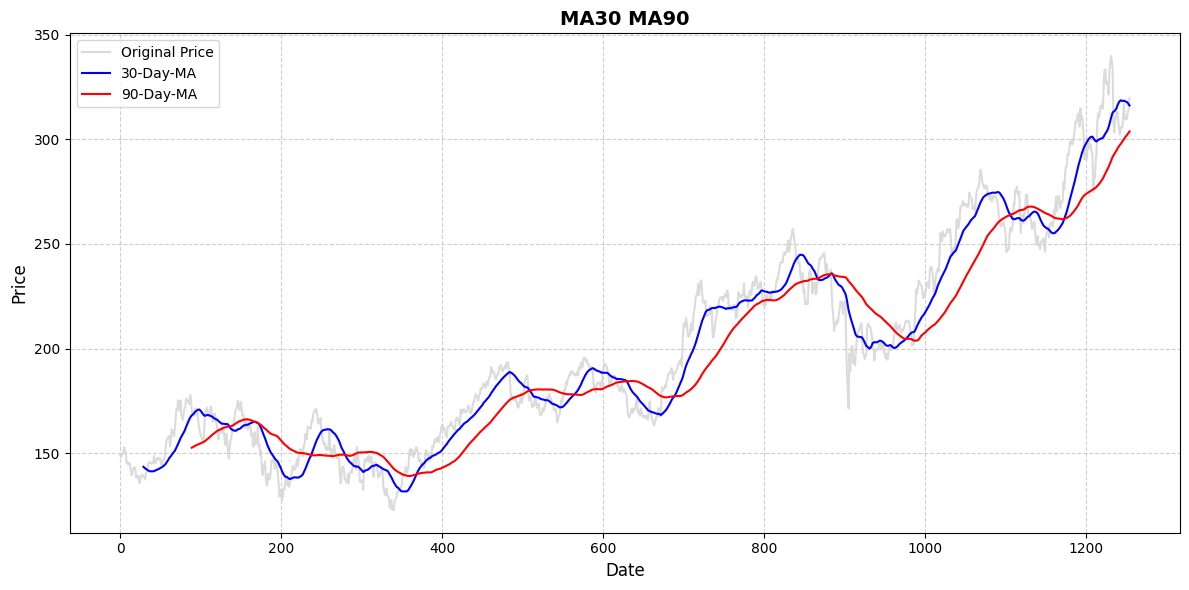

In [17]:
aapl = df[
    df["Ticker"] == "AAPL"
]

plt.figure(figsize=(12,6))

plt.plot(aapl["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(aapl["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(aapl["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

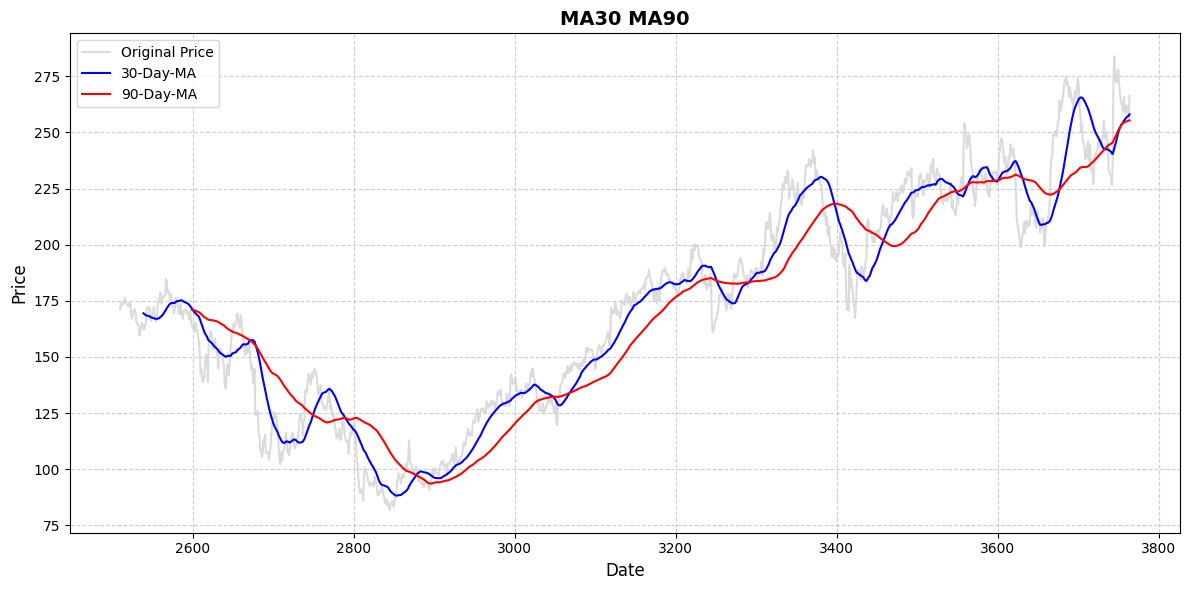

In [18]:
amzn = df[
    df["Ticker"] == "AMZN"
]

plt.figure(figsize=(12,6))

plt.plot(amzn["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(amzn["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(amzn["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

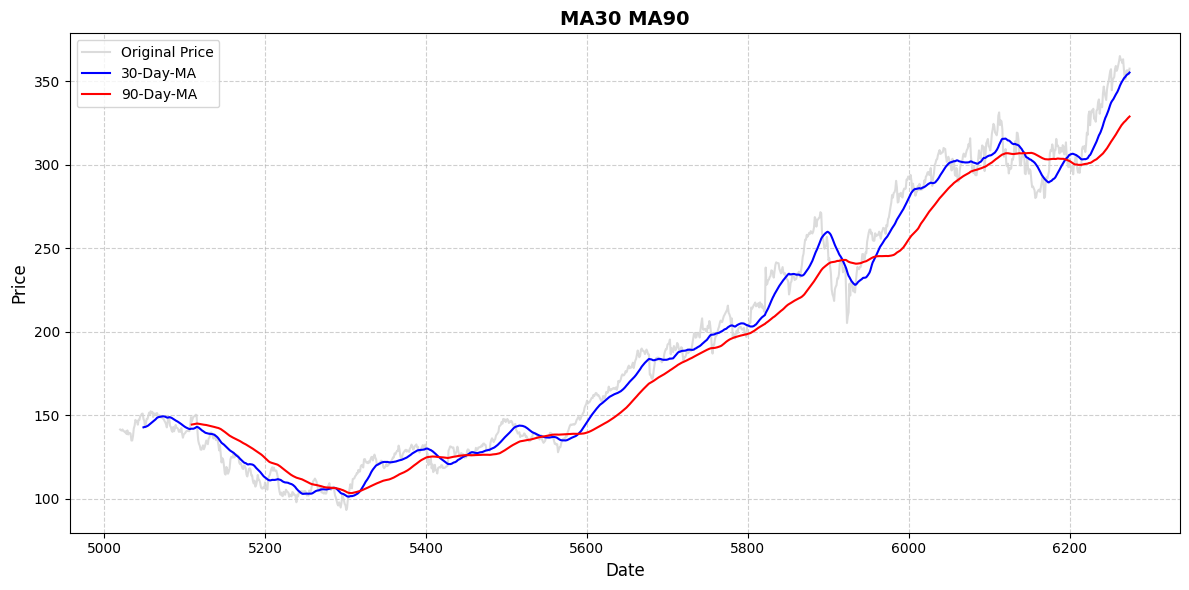

In [19]:
jpm = df[
    df["Ticker"] == "JPM"
]

plt.figure(figsize=(12,6))

plt.plot(jpm["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(jpm["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(jpm["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

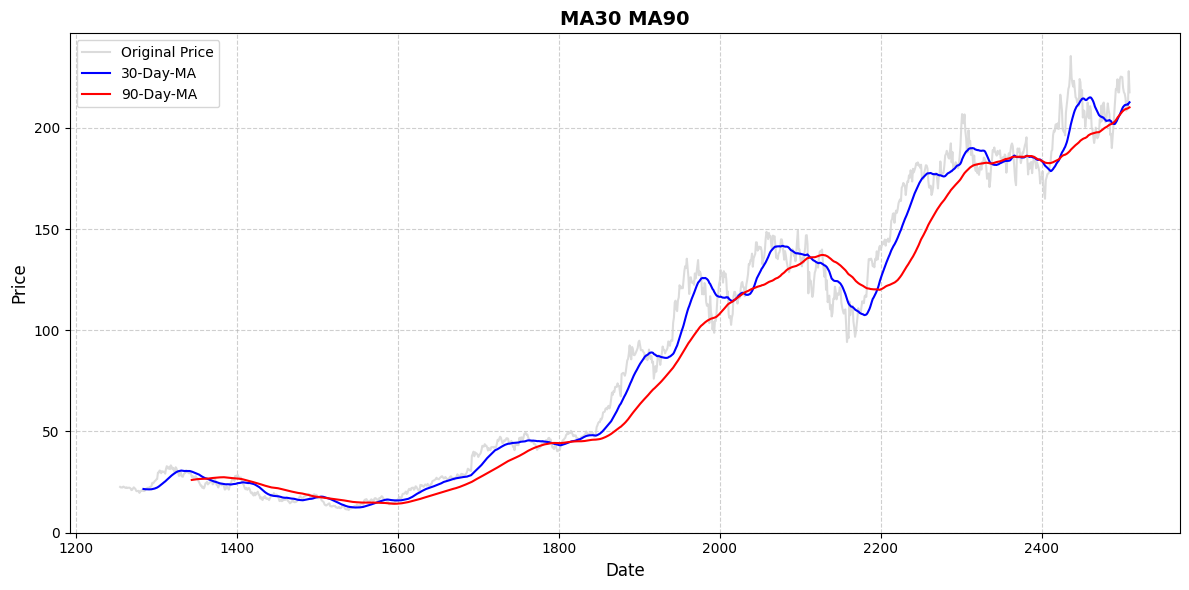

In [20]:
nvda = df[
    df["Ticker"] == "NVDA"
]

plt.figure(figsize=(12,6))

plt.plot(nvda["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(nvda["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(nvda["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

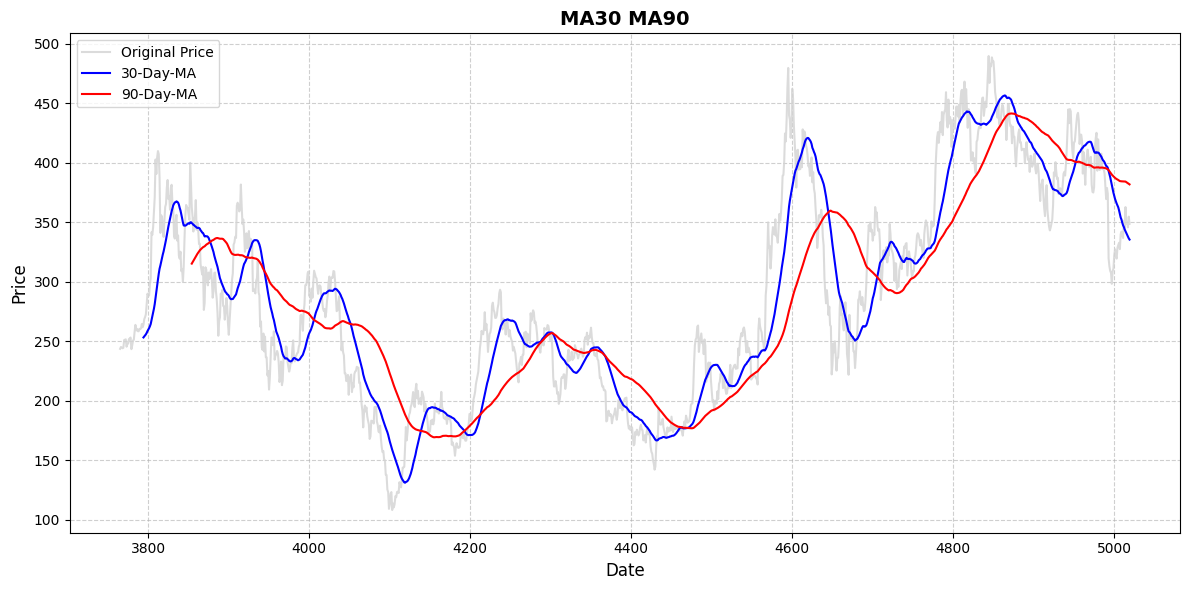

In [21]:
tsla = df[
    df["Ticker"] == "TSLA"
]

plt.figure(figsize=(12,6))

plt.plot(tsla["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(tsla["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(tsla["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
aapl = df[
    df["Ticker"] == "AAPL"
]
amzn = df[
    df["Ticker"] == "AMZN"
]
jpm = df[
    df["Ticker"] == "JPM"
]
tsla = df[
    df["Ticker"] == "TSLA"
]
nvda = df[
    df["Ticker"] == "NVDA"
]

plt.figure(figsize=(12,6))

plt.plot(tsla["Adj Close"], label="Original Price", color="lightgray", alpha=0.8)
plt.plot(tsla["MA30"], label="30-Day-MA", color="blue", linewidth=1.5)
plt.plot(tsla["MA90"], label="90-Day-MA", color="red", linewidth=1.5)

plt.title("MA30 MA90", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

